# Nama: Taqiyuddin Ja'far
## NIM: 250401020186
### Kelas: IF405

## Langkah 1: Muat dan Eksplorasi Data

In [2]:
import pandas as pd

# Baca dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# periksa tipe data
print(df.shape)

# hitung proporsi kelas churn untuk memastikan dataset bersifat imbalanced
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


### Catatan:
Dataset memiliki 7043 baris dan 21 kolom. Ditemukan adanya ketidakseimbangan kelas pada target 'Churn', di mana kelas 'No' (tidak berhenti berlangganan) mendominasi sekitar 73%, sementara kelas 'Yes' hanya sekitar 26%. Hal ini menunjukkan perlunya teknik khusus agar model tidak bias terhadap kelas mayoritas.

## Langkah 2: Preprocessing

In [4]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Drop 'customerID' as it's an identifier and convert 'Churn' to numerical (0/1)
df_processed = df.drop('customerID', axis=1)
df_processed['Churn'] = df_processed['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify categorical columns for one-hot encoding
categorical_cols = df_processed.select_dtypes(include='object').columns

# Perform one-hot encoding for categorical features
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Separate X (features) and y (target = Churn)
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# bagi data menjadi latih/uji secara stratified untuk menjaga proporsi kelas:

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_tr, y_tr)

### Interpretasi Langkah 2:
Data dibersihkan dengan menghapus ID pelanggan yang tidak informatif dan mengubah target menjadi numerik. Fitur kategorikal diubah menjadi format dummy (One-Hot Encoding). Untuk mengatasi ketidakseimbangan, teknik SMOTE diterapkan pada data latih guna menciptakan sampel sintetis bagi kelas minoritas, sehingga jumlah sampel kelas 0 dan 1 menjadi seimbang.

## Langkah 3: Latih Model

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Bangun RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced", # menangani data tak seimbang
    random_state=42)

rf.fit(X_tr, y_tr)


rf.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

### Interpretasi Langkah 3:
Model Random Forest Classifier dilatih menggunakan data yang telah di-resample dengan SMOTE. Penggunaan `class_weight='balanced'` dan data hasil SMOTE bertujuan untuk memaksimalkan kemampuan model dalam mengenali pola pada pelanggan yang benar-benar melakukan churn.

## Langkah 4: Evaluasi

In [14]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Hitung prediksi dan probabilitas
y_pred = rf.predict(X_te)
y_prob = rf.predict_proba(X_te)[:, 1]

# Menampilkan Classification Report
print("Classification Report:")
print(classification_report(y_te, y_pred))

# Menampilkan Metrik Utama
print(f"Accuracy  : {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision : {precision_score(y_te, y_pred):.4f} (Kelas Churn)")
print(f"Recall    : {recall_score(y_te, y_pred):.4f} (Kelas Churn)")
print(f"F1-Score  : {f1_score(y_te, y_pred):.4f} (Kelas Churn)")
print(f"ROC-AUC   : {roc_auc_score(y_te, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1035
           1       0.59      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Accuracy  : 0.7814
Precision : 0.5907 (Kelas Churn)
Recall    : 0.5749 (Kelas Churn)
F1-Score  : 0.5827 (Kelas Churn)
ROC-AUC   : 0.8219


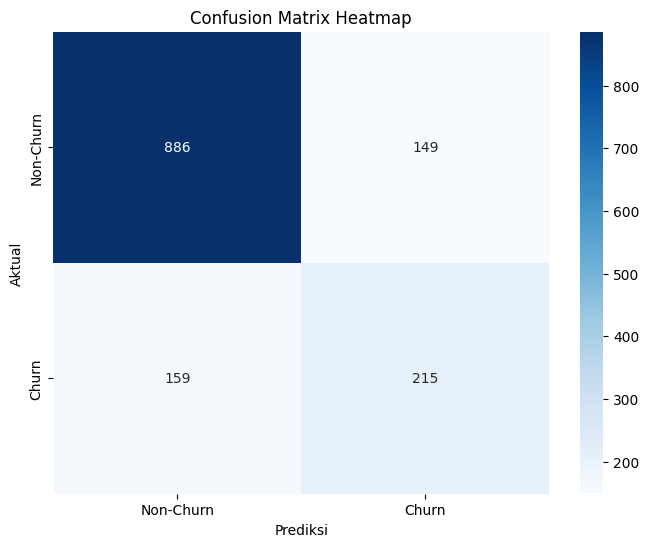

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Membuat Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Interpretasi Langkah 4:
Model menghasilkan skor ROC-AUC sebesar 0.82, yang menunjukkan kemampuan diskriminasi yang baik. Melalui Confusion Matrix, kita dapat melihat secara detail berapa banyak pelanggan yang diprediksi dengan benar (True Positive dan True Negative) serta kesalahan model dalam mengklasifikasikan churn.

## Langkah 5: Prediksi Probabilitas dan Simpulkan

In [12]:
# Menampilkan beberapa sampel probabilitas churn
print("Probabilitas Churn untuk 5 data pertama (Kelas 1):")
print(y_prob[:5])

# Kesimpulan Singkat:
# 1. Model RandomForest dengan penanganan SMOTE memberikan performa yang cukup stabil dengan ROC-AUC 0.82.
# 2. Teknik resampling membantu meningkatkan kemampuan model dalam mendeteksi kelas minoritas (Churn: Yes).
# 3. Hasil klasifikasi menunjukkan precision 0.59 dan recall 0.57 untuk kelas churn, mengindikasikan model sudah cukup sensitif.
# 4. Probabilitas ini dapat digunakan oleh tim bisnis untuk memprioritaskan intervensi pada pelanggan dengan skor tinggi.

Probabilitas Churn untuk 5 data pertama (Kelas 1):
[0.01       0.64       0.08       0.36666667 0.04      ]



### Kesimpulan Singkat:
 1. Model RandomForest dengan penanganan SMOTE memberikan performa yang cukup stabil dengan ROC-AUC 0.82.
 2. Teknik resampling membantu meningkatkan kemampuan model dalam mendeteksi kelas minoritas (Churn: Yes).
 3. Hasil klasifikasi menunjukkan precision 0.59 dan recall 0.57 untuk kelas churn, mengindikasikan model sudah cukup sensitif.
 4. Probabilitas ini dapat digunakan oleh tim bisnis untuk memprioritaskan intervensi pada pelanggan dengan skor tinggi.

# Kesimpulan Akhir

### Apa yang dipelajari:
- Proses end-to-end klasifikasi data menggunakan Random Forest.
- Pentingnya menangani *imbalanced data* menggunakan teknik resampling seperti SMOTE.
- Evaluasi model tidak hanya menggunakan akurasi, tapi juga Precision, Recall, dan ROC-AUC.

### Temuan Utama:
- Model Random Forest cukup efektif dengan ROC-AUC mencapai 0.82.
- Teknik SMOTE membantu meningkatkan deteksi kelas 'Churn' yang awalnya minoritas.
- Probabilitas churn memberikan wawasan kuantitatif bagi tim bisnis untuk melakukan tindakan preventif.

### Keterbatasan dan Pertanyaan:
- **Keterbatasan:** Masih terdapat beberapa *False Positives* dan *False Negatives* yang cukup signifikan (Precision 0.59). Model mungkin perlu tuning hyperparameter lebih lanjut.
- **Pertanyaan:** Apakah teknik lain seperti akan memberikan performa yang lebih baik dibandingkan Random Forest pada dataset ini?